# Clasificacion comportamiento conductor
**Modelos:** MobileNetV2 · ResNet50 · EfficientNet-B0  
**Dataset:** Multi-Class Driver Behavior Image Dataset (Kaggle)

Ejecuta las celdas **en orden**. Todo se guarda en `results/` y `saved_models/`.


## 1 · Importacion de librerias

In [9]:
# ── Stdlib ────────────────────────────────────────────────────────────────────
import os
import re
import random

# ── Numérico ──────────────────────────────────────────────────────────────────
import numpy as np

# ── PyTorch ───────────────────────────────────────────────────────────────────
import torch
import torch.nn as nn
from torchvision import datasets, models, transforms
from torch.utils.data import DataLoader, Subset

# ── Scikit-learn ──────────────────────────────────────────────────────────────
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.preprocessing import label_binarize
from sklearn.utils.class_weight import compute_class_weight

# ── Visualización ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns

# ── Utilidades ────────────────────────────────────────────────────────────────
import kagglehub
from tqdm.auto import tqdm

## 2 · Configuración global

In [2]:

# ── Hiperparámetros ──────────────────────────────────────────────────────────
IMG_SIZE    = (224, 224)
BATCH_SIZE  = 32
EPOCHS      = 30
NUM_WORKERS = 0
SEED        = 42
NUM_CLASSES = 5
PATIENCE    = 6

CLASES = [
    "safe_driving",
    "talking_phone",
    "texting_phone",
    "other_activities",
    "turning",
]
CLASES_CRITICAS = ["talking_phone", "texting_phone"]

MODELS_DIR  = "saved_models"
RESULTS_DIR = "results"

# ── Reproducibilidad ─────────────────────────────────────────────────────────
def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed()
os.makedirs(MODELS_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Config lista | device={DEVICE} | EPOCHS={EPOCHS} | BATCH_SIZE={BATCH_SIZE}")


Config lista | device=cuda | EPOCHS=30 | BATCH_SIZE=32


## 3 · Descarga automática del dataset (Kaggle)

In [3]:


print("Descargando dataset...")
DATASET_PATH = kagglehub.dataset_download(
    "arafatsahinafridi/multi-class-driver-behavior-image-dataset"
)

# Buscar la carpeta raíz con las clases
for root, dirs, files in os.walk(DATASET_PATH):
    if any(c in dirs for c in CLASES):
        DATASET_PATH = root
        break

print(f"Dataset listo en: {DATASET_PATH}")
print("Carpetas encontradas:", os.listdir(DATASET_PATH))


Descargando dataset...
Dataset listo en: C:\Users\dfgar\.cache\kagglehub\datasets\arafatsahinafridi\multi-class-driver-behavior-image-dataset\versions\1\Multi-Class Driver Behavior Image Dataset
Carpetas encontradas: ['other_activities', 'safe_driving', 'talking_phone', 'texting_phone', 'turning']


## 4 · Análisis exploratorio (EDA)

Conteo por clase: {'other_activities': 1184, 'safe_driving': 1679, 'talking_phone': 1513, 'texting_phone': 1561, 'turning': 1339}


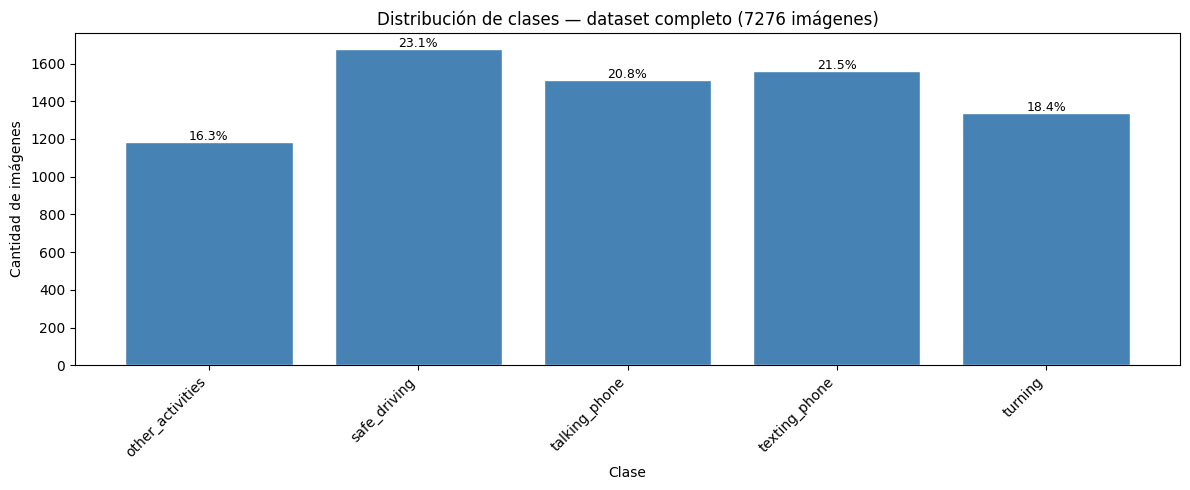

Balance aceptable | ratio max/min = 1.4x


In [4]:


def contar_imagenes_por_clase(path=DATASET_PATH):
    exts = {".jpg", ".jpeg", ".png", ".bmp"}
    return {
        clase: len([f for f in os.listdir(os.path.join(path, clase))
                    if os.path.splitext(f)[1].lower() in exts])
        for clase in os.listdir(path)
        if os.path.isdir(os.path.join(path, clase))
    }

def plot_distribucion(conteo, titulo="dataset completo"):
    clases  = list(conteo.keys())
    valores = list(conteo.values())
    total   = sum(valores)

    fig, ax = plt.subplots(figsize=(12, 5))
    bars = ax.bar(clases, valores, color="steelblue", edgecolor="white")
    ax.set_title(f"Distribución de clases — {titulo} ({total} imágenes)")
    ax.set_xlabel("Clase"); ax.set_ylabel("Cantidad de imágenes")
    plt.xticks(rotation=45, ha="right")
    for bar, v in zip(bars, valores):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 10,
                f"{v/total*100:.1f}%", ha="center", fontsize=9)
    plt.tight_layout()
    plt.savefig(f"{RESULTS_DIR}/distribucion_clases.png", dpi=150)
    plt.show()

    ratio = max(valores) / min(valores)
    msg = "DESBALANCE SEVERO → se usará class_weight" if ratio > 3 else "Balance aceptable"
    print(f"{msg} | ratio max/min = {ratio:.1f}x")
    return ratio

conteo = contar_imagenes_por_clase()
print("Conteo por clase:", conteo)
ratio  = plot_distribucion(conteo)


## 5 · Dataset splits y DataLoaders

In [ ]:

def get_transforms():
    # Los valores para normalizacion son estandar para modelos preentrenados en ImageNet
    train_tf = transforms.Compose([
        transforms.Resize(IMG_SIZE),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(15),
        transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
        transforms.RandomGrayscale(p=0.05),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
    ])
    val_tf = transforms.Compose([
        transforms.Resize(IMG_SIZE),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
    ])
    return train_tf, val_tf

def get_dataloaders(path=DATASET_PATH):
    train_tf, val_tf = get_transforms()
    full_train = datasets.ImageFolder(path, transform=train_tf)
    full_eval  = datasets.ImageFolder(path, transform=val_tf)

    # Dividir el dataset completo en train/val/test (80/10/10) de forma aleatoria pero reproducible
    n       = len(full_train)
    n_train = int(0.8 * n)
    n_val   = int(0.1 * n)

    # Mezclar los índices de forma reproducible
    g    = torch.Generator().manual_seed(SEED)
    perm = torch.randperm(n, generator=g).tolist()
    train_idx = perm[:n_train]
    val_idx   = perm[n_train:n_train + n_val]
    test_idx  = perm[n_train + n_val:]

    train_ds = Subset(full_train, train_idx)
    val_ds   = Subset(full_eval,  val_idx)
    test_ds  = Subset(full_eval,  test_idx)

    labels = [full_train.targets[i] for i in train_idx]
    class_weights = compute_class_weight("balanced",
                                          classes=np.unique(labels), y=labels)
    cw_tensor = torch.FloatTensor(class_weights)

    loaders = {
        "train": DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=NUM_WORKERS),
        "val":   DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS),
        "test":  DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS),
    }
    return loaders, cw_tensor, full_train.classes

loaders, class_weights, clases = get_dataloaders()
print(f"Splits: train={len(loaders['train'].dataset)} | "
      f"val={len(loaders['val'].dataset)} | "
      f"test={len(loaders['test'].dataset)}")
print("Clases:", clases)


Splits: train=5820 | val=727 | test=729
Clases: ['other_activities', 'safe_driving', 'talking_phone', 'texting_phone', 'turning']


## 6 · Definición de modelos (transfer learning + fine-tuning)

In [6]:

def build_model(nombre: str, freeze_base=True):
    if nombre == "mobilenet":
        model = models.mobilenet_v2(weights="IMAGENET1K_V1")
        if freeze_base:
            for p in model.features.parameters():
                p.requires_grad = False
        model.classifier = nn.Sequential(
            nn.Dropout(0.4),
            nn.Linear(model.last_channel, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, NUM_CLASSES),
        )

    elif nombre == "resnet50":
        model = models.resnet50(weights="IMAGENET1K_V1")
        if freeze_base:
            for name, p in model.named_parameters():
                if "layer4" not in name:
                    p.requires_grad = False
        model.fc = nn.Sequential(
            nn.Dropout(0.4),
            nn.Linear(2048, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, NUM_CLASSES),
        )

    elif nombre == "efficientnet":
        model = models.efficientnet_b0(weights="IMAGENET1K_V1")
        if freeze_base:
            for p in model.features.parameters():
                p.requires_grad = False
        in_features = model.classifier[1].in_features
        model.classifier = nn.Sequential(
            nn.Dropout(0.4),
            nn.Linear(in_features, NUM_CLASSES),
        )
    else:
        raise ValueError(f"Modelo '{nombre}' no reconocido")

    return model

# Verificación rápida de parámetros entrenables
for nombre in ["mobilenet", "resnet50", "efficientnet"]:
    m = build_model(nombre)
    total     = sum(p.numel() for p in m.parameters())
    trainable = sum(p.numel() for p in m.parameters() if p.requires_grad)
    print(f"{nombre:12s} → entrenables: {trainable:,} / {total:,} ({trainable/total*100:.1f}%)")


mobilenet    → entrenables: 329,221 / 2,553,093 (12.9%)
resnet50     → entrenables: 16,016,389 / 24,559,685 (65.2%)
efficientnet → entrenables: 6,405 / 4,013,953 (0.2%)


## 7 · Entrenamiento

In [ ]:

def plot_curvas(history, nombre):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    ax1.plot(history["train_loss"], label="Train")
    ax1.plot(history["val_loss"],   label="Val")
    ax1.set_title(f"{nombre} — Loss"); ax1.set_xlabel("Epoch"); ax1.legend()
    ax2.plot(history["train_acc"], label="Train")
    ax2.plot(history["val_acc"],   label="Val")
    ax2.set_title(f"{nombre} — Accuracy"); ax2.set_xlabel("Epoch"); ax2.legend()
    plt.tight_layout()
    plt.savefig(f"{RESULTS_DIR}/curvas_{nombre}.png", dpi=150)
    plt.show()

def entrenar(nombre_modelo, loaders, class_weights, patience=PATIENCE):
    print(f"\n{'='*50}")
    print(f"  Entrenando: {nombre_modelo.upper()} en {DEVICE}")
    print(f"{'='*50}")

    model     = build_model(nombre_modelo).to(DEVICE)
    criterion = nn.CrossEntropyLoss(weight=class_weights.to(DEVICE))
    optimizer = torch.optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=1e-3, weight_decay=1e-4,
    )
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, patience=3, factor=0.3,
    )

    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
    best_val_loss   = float("inf")
    epochs_sin_mejora = 0

    for epoch in range(EPOCHS):
        metricas = {}
        for phase in ["train", "val"]:
            model.train() if phase == "train" else model.eval()
            total_loss = correct = total = 0

            for i, (imgs, labels) in enumerate(loaders[phase]):
                
                if i % 50 == 0:
                    print(f"Epoch {epoch+1}/{EPOCHS} [{phase}] batch {i}/{len(loaders[phase])}", 
                        flush=True)
                
                imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
                optimizer.zero_grad()
                with torch.set_grad_enabled(phase == "train"):
                    outputs = model(imgs)
                    loss    = criterion(outputs, labels)
                    if phase == "train":
                        loss.backward()
                        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                        optimizer.step()
                total_loss += loss.item() * imgs.size(0)
                _, preds = outputs.max(1)
                correct  += preds.eq(labels).sum().item()
                total    += labels.size(0)

            e_loss = total_loss / total
            e_acc  = correct   / total
            history[f"{phase}_loss"].append(e_loss)
            history[f"{phase}_acc"].append(e_acc)
            metricas[phase] = (e_loss, e_acc)

        tl, ta = metricas["train"]
        vl, va = metricas["val"]
        lr_now = optimizer.param_groups[0]["lr"]
        print(f"Epoch {epoch+1:02d}/{EPOCHS} | "
              f"train loss={tl:.4f} acc={ta:.3f} | "
              f"val loss={vl:.4f} acc={va:.3f} | lr={lr_now:.2e}")

        scheduler.step(vl)
        if vl < best_val_loss:
            best_val_loss = vl
            epochs_sin_mejora = 0
            torch.save(model.state_dict(), f"{MODELS_DIR}/best_{nombre_modelo}.pth")
            print(f"Guardado (best val_loss={best_val_loss:.4f})")
        else:
            epochs_sin_mejora += 1
            if epochs_sin_mejora >= patience:
                print(f"Early stopping tras {patience} épocas sin mejora")
                break
    
    model.load_state_dict(torch.load(f"{MODELS_DIR}/best_{nombre_modelo}.pth",map_location=DEVICE, weights_only=True))

    plot_curvas(history, nombre_modelo)

    return model, history


### 7.1 · Entrenar los 3 modelos


  Entrenando: MOBILENET en cuda


Epoch 1/30 [val]: 100%|██████████| 23/23 [00:13<00:00,  1.75it/s]


Epoch 01/30 | train loss=1.4112 acc=0.408 | val loss=1.2128 acc=0.484 | lr=1.00e-03
Guardado (best val_loss=1.2128)


Epoch 2/30 [val]: 100%|██████████| 23/23 [00:14<00:00,  1.59it/s]


Epoch 02/30 | train loss=1.2261 acc=0.519 | val loss=1.0188 acc=0.649 | lr=1.00e-03
Guardado (best val_loss=1.0188)


...

Epoch 28/30 | train loss=0.8685 acc=0.662 | val loss=0.6576 acc=0.792 | lr=1.00e-03


Epoch 29/30 [val]: 100%|██████████| 23/23 [00:18<00:00,  1.26it/s]


Epoch 29/30 | train loss=0.8495 acc=0.672 | val loss=0.6178 acc=0.813 | lr=3.00e-04
Guardado (best val_loss=0.6178)


Epoch 30/30 [val]: 100%|██████████| 23/23 [00:19<00:00,  1.20it/s]


Epoch 30/30 | train loss=0.8550 acc=0.682 | val loss=0.6207 acc=0.805 | lr=3.00e-04


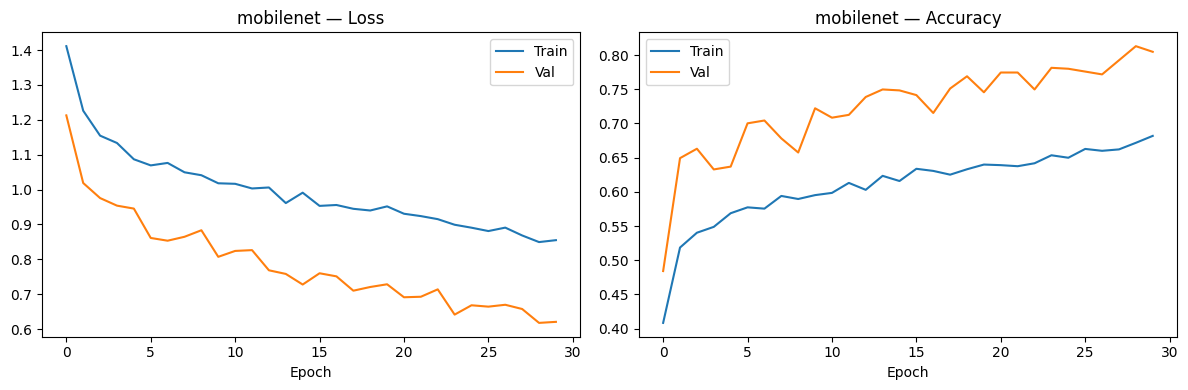


  Entrenando: RESNET50 en cuda


Epoch 1/30 [val]: 100%|██████████| 23/23 [00:12<00:00,  1.85it/s]


Epoch 01/30 | train loss=0.6181 acc=0.771 | val loss=0.3162 acc=0.876 | lr=1.00e-03
Guardado (best val_loss=0.3162)


Epoch 2/30 [val]: 100%|██████████| 23/23 [00:15<00:00,  1.51it/s]


Epoch 02/30 | train loss=0.3488 acc=0.881 | val loss=0.2603 acc=0.915 | lr=1.00e-03
Guardado (best val_loss=0.2603)


...

Epoch 14/30 | train loss=0.0687 acc=0.974 | val loss=0.1100 acc=0.963 | lr=3.00e-04


Epoch 15/30 [val]: 100%|██████████| 23/23 [00:14<00:00,  1.55it/s]


Epoch 15/30 | train loss=0.0581 acc=0.978 | val loss=0.1083 acc=0.961 | lr=9.00e-05


Epoch 16/30 [val]: 100%|██████████| 23/23 [00:14<00:00,  1.56it/s]


Epoch 16/30 | train loss=0.0487 acc=0.981 | val loss=0.1035 acc=0.966 | lr=9.00e-05
Early stopping tras 6 épocas sin mejora


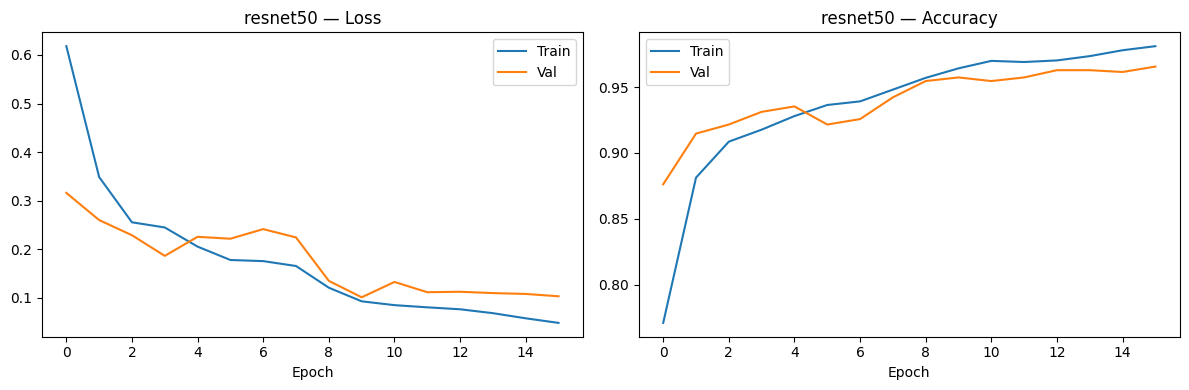


  Entrenando: EFFICIENTNET en cuda


Epoch 1/30 [val]: 100%|██████████| 23/23 [00:14<00:00,  1.64it/s]


Epoch 01/30 | train loss=1.4025 acc=0.447 | val loss=1.2735 acc=0.582 | lr=1.00e-03
Guardado (best val_loss=1.2735)


Epoch 2/30 [val]: 100%|██████████| 23/23 [00:14<00:00,  1.61it/s]


Epoch 02/30 | train loss=1.1834 acc=0.561 | val loss=1.1261 acc=0.612 | lr=1.00e-03
Guardado (best val_loss=1.1261)


...

Epoch 28/30 | train loss=0.9623 acc=0.633 | val loss=0.8167 acc=0.737 | lr=3.00e-04
Guardado (best val_loss=0.8167)


Epoch 29/30 [val]: 100%|██████████| 23/23 [00:11<00:00,  1.93it/s]


Epoch 29/30 | train loss=0.9664 acc=0.637 | val loss=0.8269 acc=0.715 | lr=3.00e-04


Epoch 30/30 [val]: 100%|██████████| 23/23 [00:11<00:00,  1.95it/s]


Epoch 30/30 | train loss=0.9760 acc=0.628 | val loss=0.8270 acc=0.714 | lr=3.00e-04


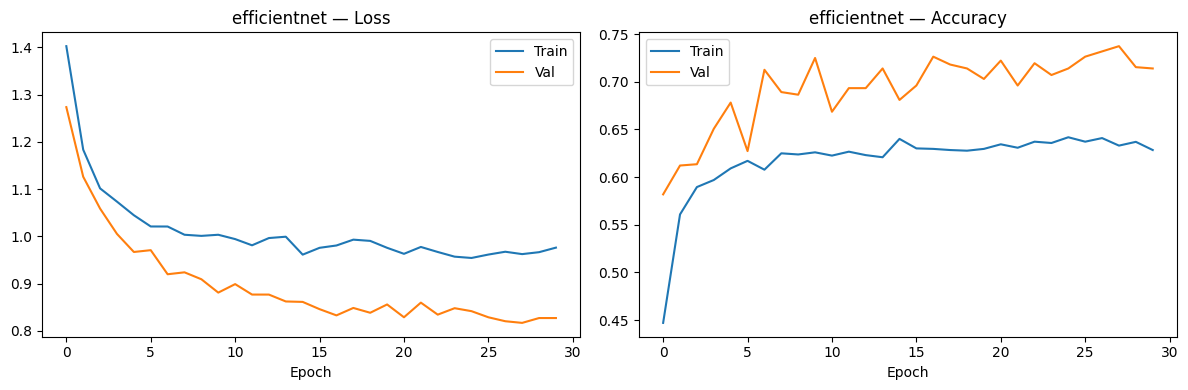


Entrenamiento completado para todos los modelos


In [13]:
MODELOS = ["mobilenet", "resnet50", "efficientnet"]
historial = {}

for modelo in MODELOS:
    _, hist = entrenar(modelo, loaders, class_weights)
    historial[modelo] = hist

print("\nEntrenamiento completado para todos los modelos")


## 8 · Evaluación

In [14]:

def evaluar(nombre_modelo, loaders, clases):
    print(f"\n{'='*50}")
    print(f"  Evaluando: {nombre_modelo.upper()}")
    print(f"{'='*50}")

    model = build_model(nombre_modelo)
    state = torch.load(f"{MODELS_DIR}/best_{nombre_modelo}.pth",
                       map_location=DEVICE, weights_only=True)
    model.load_state_dict(state)
    model.eval().to(DEVICE)

    all_preds, all_labels, all_probs = [], [], []
    with torch.no_grad():
        for imgs, labels in tqdm(loaders["test"], desc="Test", leave=False):
            imgs    = imgs.to(DEVICE)
            outputs = model(imgs)
            probs   = torch.softmax(outputs, dim=1)
            _, preds = probs.max(1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())
            all_probs.extend(probs.cpu().numpy())

    all_probs = np.array(all_probs)

    # ── Classification report ────────────────────────────────────────────────
    reporte_txt = classification_report(all_labels, all_preds,
                                        target_names=clases, digits=3)
    print("\nClassification Report:\n", reporte_txt)

    # ── AUC-ROC ──────────────────────────────────────────────────────────────
    y_bin = label_binarize(all_labels, classes=range(NUM_CLASSES))
    auc   = roc_auc_score(y_bin, all_probs, multi_class="ovr", average="macro")
    print(f"AUC-ROC macro: {auc:.4f}")

    # ── Recall clases críticas ───────────────────────────────────────────────
    report = classification_report(all_labels, all_preds,
                                   target_names=clases, output_dict=True)
    print("\nRecall en clases críticas:")
    for c in CLASES_CRITICAS:
        r = report.get(c, {}).get("recall", None)
        print(f"  {c}: {r:.3f}" if r is not None else f"  {c}: (no aparece en test)")

    # ── Guardar reporte txt ──────────────────────────────────────────────────
    ruta = f"{RESULTS_DIR}/reporte_{nombre_modelo}.txt"
    with open(ruta, "w", encoding="utf-8") as f:
        f.write(f"Modelo: {nombre_modelo}\n{'='*50}\n\n")
        f.write(f"Classification Report:\n{reporte_txt}\n")
        f.write(f"AUC-ROC macro: {auc:.4f}\n\nRecall clases críticas:\n")
        for c in CLASES_CRITICAS:
            r = report.get(c, {}).get("recall", None)
            f.write(f"  {c}: {r:.3f}\n" if r is not None else f"  {c}: N/A\n")
    print(f"\nReporte guardado → {ruta}")

    # ── Matriz de confusión ──────────────────────────────────────────────────
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(9, 7))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=clases, yticklabels=clases)
    plt.title(f"Matriz de confusión — {nombre_modelo}")
    plt.tight_layout()
    ruta_cm = f"{RESULTS_DIR}/confusion_{nombre_modelo}.png"
    plt.savefig(ruta_cm, dpi=150)
    plt.show()
    print(f"Matriz guardada → {ruta_cm}")


### 8.1 · Evaluar los 3 modelos


  Evaluando: MOBILENET



Classification Report:
                   precision    recall  f1-score   support

other_activities      0.546     0.690     0.610       129
    safe_driving      0.761     0.807     0.783       150
   talking_phone      0.906     0.844     0.874       160
   texting_phone      0.822     0.758     0.789       165
         turning      0.943     0.800     0.866       125

        accuracy                          0.782       729
       macro avg      0.796     0.780     0.784       729
    weighted avg      0.800     0.782     0.788       729

AUC-ROC macro: 0.9547

Recall en clases críticas:
  talking_phone: 0.844
  texting_phone: 0.758

Reporte guardado → results/reporte_mobilenet.txt


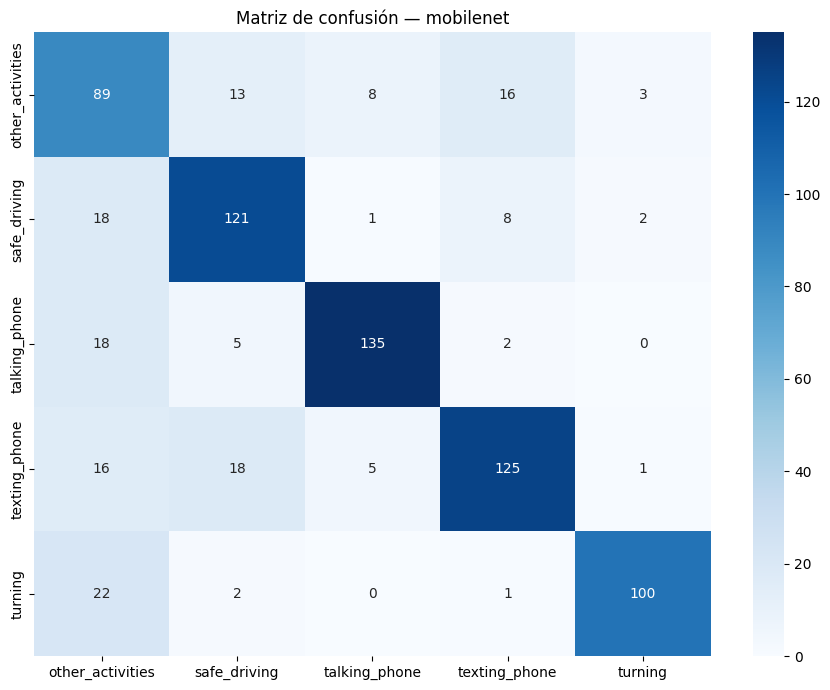

Matriz guardada → results/confusion_mobilenet.png

  Evaluando: RESNET50



Classification Report:
                   precision    recall  f1-score   support

other_activities      0.889     0.930     0.909       129
    safe_driving      0.924     0.893     0.908       150
   talking_phone      0.981     0.994     0.988       160
   texting_phone      0.988     0.970     0.979       165
         turning      0.936     0.936     0.936       125

        accuracy                          0.947       729
       macro avg      0.944     0.945     0.944       729
    weighted avg      0.947     0.947     0.947       729

AUC-ROC macro: 0.9972

Recall en clases críticas:
  talking_phone: 0.994
  texting_phone: 0.970

Reporte guardado → results/reporte_resnet50.txt


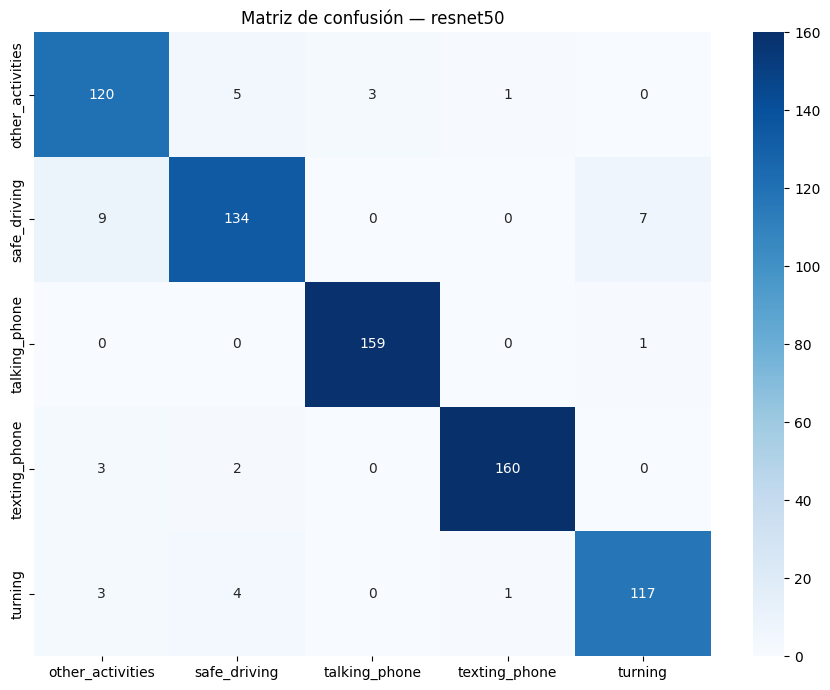

Matriz guardada → results/confusion_resnet50.png

  Evaluando: EFFICIENTNET



Classification Report:
                   precision    recall  f1-score   support

other_activities      0.606     0.488     0.541       129
    safe_driving      0.728     0.713     0.721       150
   talking_phone      0.765     0.794     0.779       160
   texting_phone      0.709     0.782     0.744       165
         turning      0.777     0.808     0.792       125

        accuracy                          0.723       729
       macro avg      0.717     0.717     0.715       729
    weighted avg      0.719     0.723     0.719       729

AUC-ROC macro: 0.9070

Recall en clases críticas:
  talking_phone: 0.794
  texting_phone: 0.782

Reporte guardado → results/reporte_efficientnet.txt


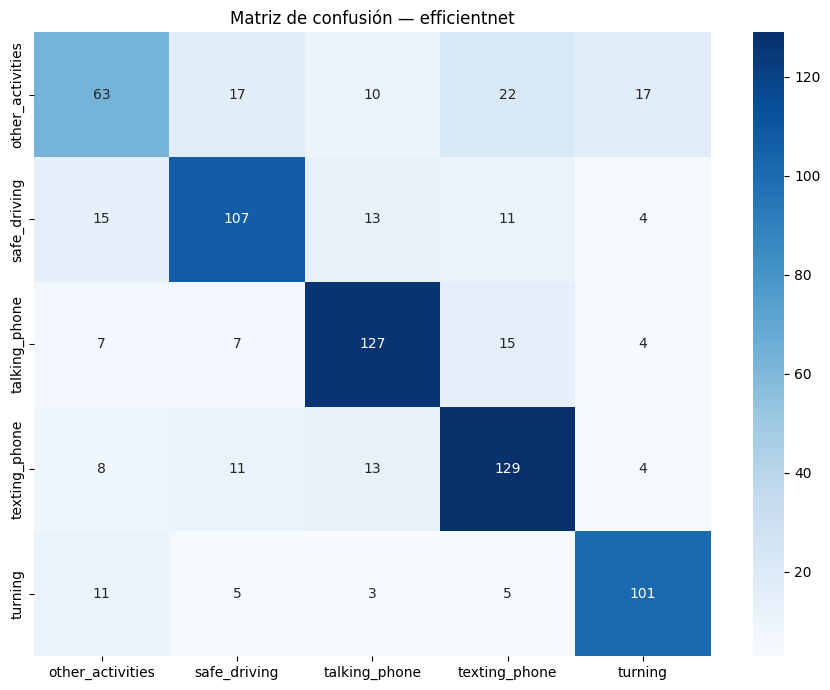

Matriz guardada → results/confusion_efficientnet.png

Evaluación completa. Revisa la carpeta results/


In [15]:
for modelo in MODELOS:
    evaluar(modelo, loaders, clases)

print("\nEvaluación completa. Revisa la carpeta results/")


## 9 · Comparativa de modelos

In [16]:

resumen = {}
for modelo in MODELOS:
    ruta = f"{RESULTS_DIR}/reporte_{modelo}.txt"
    with open(ruta, encoding="utf-8") as f:
        txt = f.read()
    acc_match = re.search(r"accuracy\s+([\d.]+)", txt)
    auc_match = re.search(r"AUC-ROC macro:\s+([\d.]+)", txt)
    resumen[modelo] = {
        "accuracy": float(acc_match.group(1)) if acc_match else None,
        "auc_roc":  float(auc_match.group(1)) if auc_match else None,
    }

print(f"{'Modelo':<15} {'Accuracy':>10} {'AUC-ROC':>10}")
print("-" * 38)
for modelo, vals in resumen.items():
    acc = f"{vals['accuracy']:.3f}" if vals['accuracy'] else "N/A"
    auc = f"{vals['auc_roc']:.4f}"  if vals['auc_roc']  else "N/A"
    print(f"{modelo:<15} {acc:>10} {auc:>10}")

mejor = max(resumen, key=lambda m: resumen[m]["auc_roc"] or 0)
print(f"\nMejor modelo por AUC-ROC: {mejor.upper()}")


Modelo            Accuracy    AUC-ROC
--------------------------------------
mobilenet            0.782     0.9547
resnet50             0.947     0.9972
efficientnet         0.723     0.9070

Mejor modelo por AUC-ROC: RESNET50


## 10 · Ejemplos de predicciones correctas e incorrectas


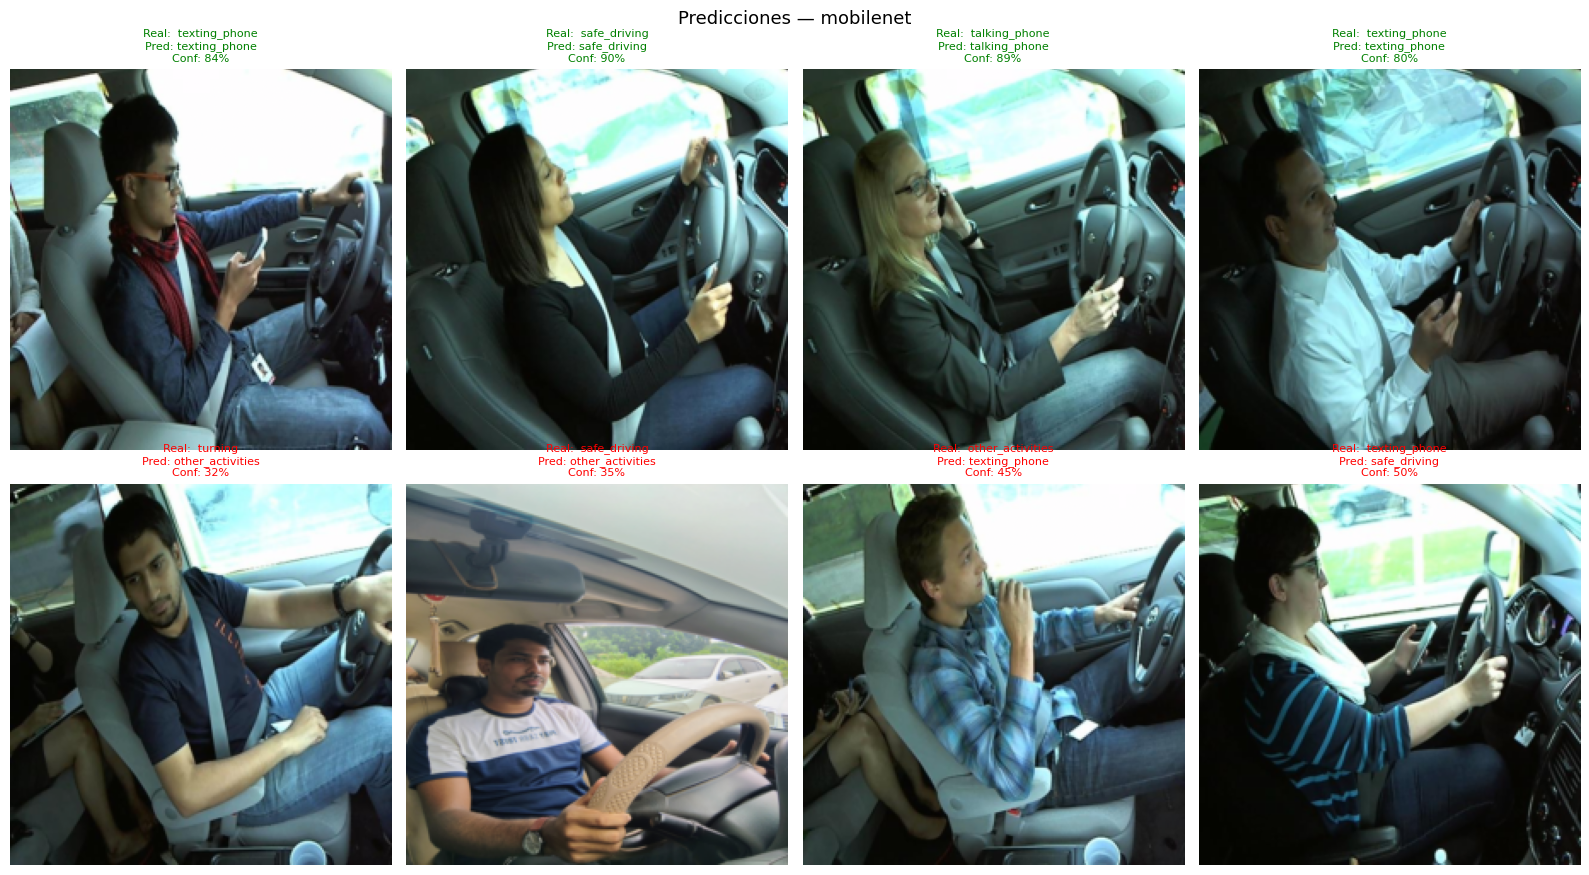

Guardado → results/predicciones_mobilenet.png


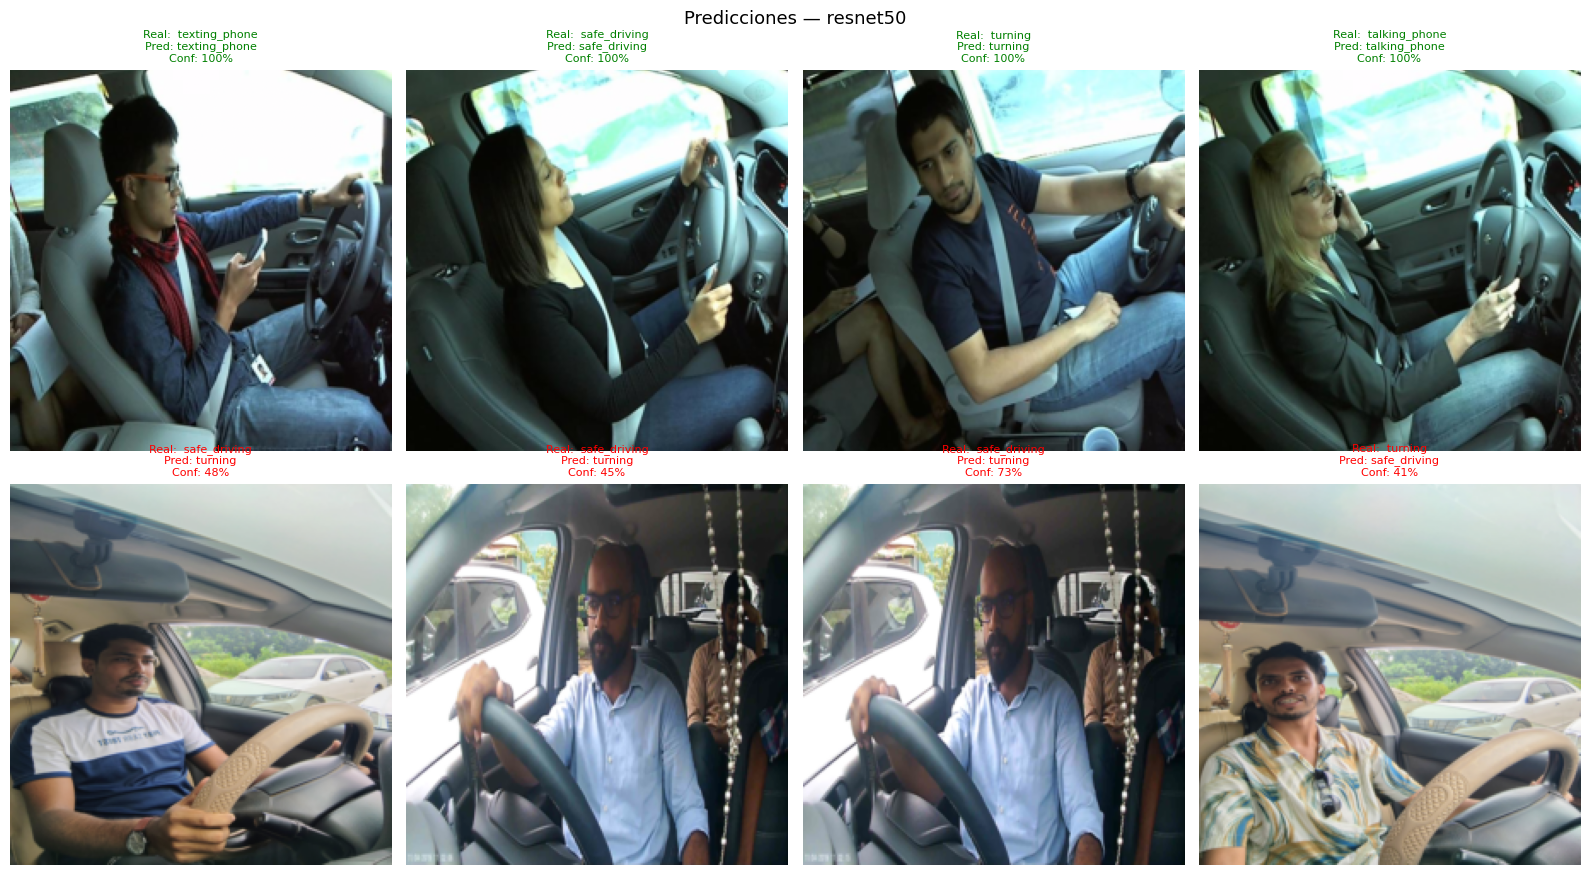

Guardado → results/predicciones_resnet50.png


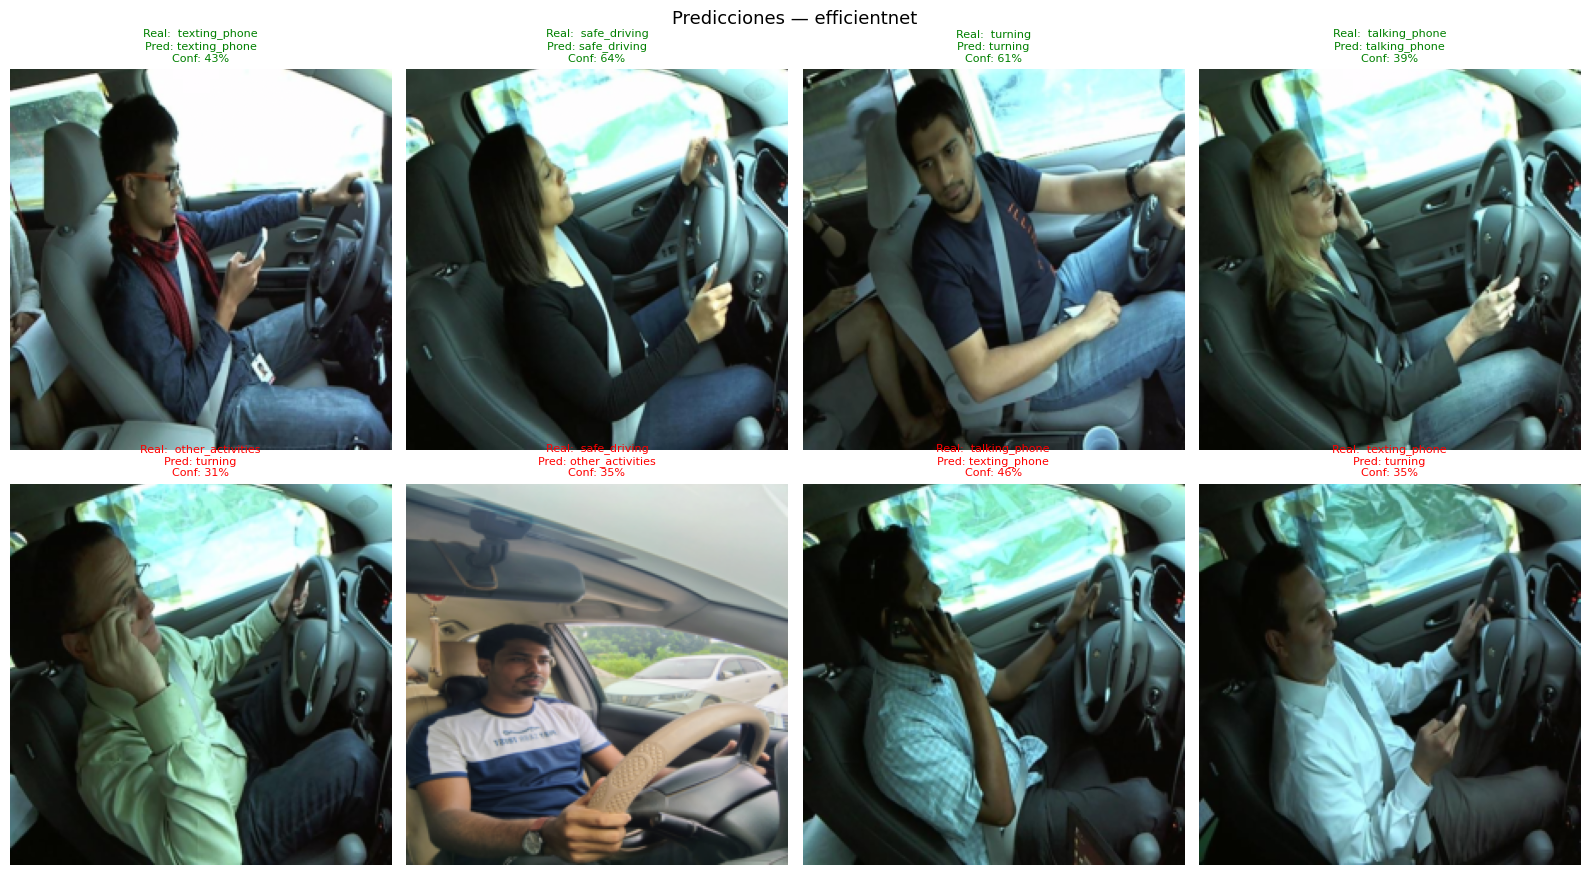

Guardado → results/predicciones_efficientnet.png


In [17]:
def mostrar_predicciones(nombre_modelo, loaders, clases, n_por_tipo=4):
    mean = torch.tensor([0.485, 0.456, 0.406])
    std  = torch.tensor([0.229, 0.224, 0.225])

    def denorm(t):
        return (t * std[:, None, None] + mean[:, None, None]).clamp(0, 1).permute(1, 2, 0).numpy()

    model = build_model(nombre_modelo)
    model.load_state_dict(torch.load(f"{MODELS_DIR}/best_{nombre_modelo}.pth",
                                      map_location=DEVICE, weights_only=True))
    model.eval().to(DEVICE)

    correctas, incorrectas = [], []
    with torch.no_grad():
        for imgs, labels in loaders["test"]:
            probs = torch.softmax(model(imgs.to(DEVICE)), dim=1).cpu()
            confs, preds = probs.max(1)
            for img, true, pred, conf in zip(imgs, labels, preds, confs):
                item = (img, true.item(), pred.item(), conf.item())
                if true == pred and len(correctas) < n_por_tipo:
                    correctas.append(item)
                elif true != pred and len(incorrectas) < n_por_tipo:
                    incorrectas.append(item)
            if len(correctas) >= n_por_tipo and len(incorrectas) >= n_por_tipo:
                break

    fig, axes = plt.subplots(2, n_por_tipo, figsize=(4 * n_por_tipo, 9))
    for fila, (grupo, color, titulo) in enumerate([
        (correctas,   "green", "✓ Correctas"),
        (incorrectas, "red",   "✗ Incorrectas"),
    ]):
        for col, (img, true, pred, conf) in enumerate(grupo):
            ax = axes[fila][col]
            ax.imshow(denorm(img))
            ax.set_title(f"Real:  {clases[true]}\nPred: {clases[pred]}\nConf: {conf:.0%}",
                         color=color, fontsize=8)
            ax.axis("off")
        axes[fila][0].set_ylabel(titulo, fontsize=11, color=color, labelpad=10)

    plt.suptitle(f"Predicciones — {nombre_modelo}", fontsize=13)
    plt.tight_layout()
    out = f"{RESULTS_DIR}/predicciones_{nombre_modelo}.png"
    plt.savefig(out, dpi=150)
    plt.show()
    print(f"Guardado → {out}")

for modelo in MODELOS:
    mostrar_predicciones(modelo, loaders, clases)